In [1]:
import pickle
import pandas as pd
import NB
import digitalization

data = pd.read_csv("original_data.csv")
digitalization.train(data)

NB.NB_model(factor_number=7, test_data_number=0.2)

df = pd.read_csv("data_to_predict.csv")
dataset = df.drop(['ENGG2020'],axis=1)
digitalization.predict(dataset)

X = dataset.iloc[:,1:7].values

# Load the SVM model (if saved)
with open('NB.pickle', 'rb') as model_file:
    NB = pickle.load(model_file)

# Predicting the Test set results
y_pred = NB.predict(X)
print('Number of predictions: ', len(y_pred))
nb_df=pd.DataFrame(y_pred)
nb_df.columns = ['ENGG2020']
pd.DataFrame(nb_df).to_csv('NB_pred_level.csv',index=None)
f1 = pd.read_csv('predict_data.csv')
f2 = pd.read_csv('NB_pred_level.csv')
file = [f1,f2]
train = pd.concat(file,axis=1)
train.to_csv("NB_predict_complete" + ".csv", index=0, sep=',')

Accuracy of the Naive Bayes Clasification is:  0.9908256880733946
Number of predictions:  545


Show the relationships between the amount of training data and accuracy.
(Run the first program first)

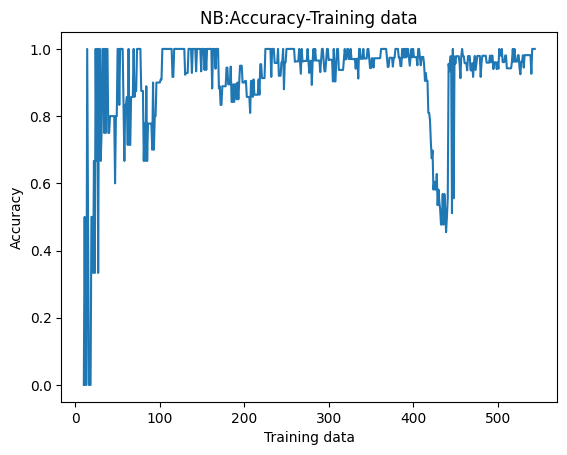

In [2]:
import NB_Comparison
import matplotlib.pyplot as plt

dataset = pd.read_csv('train_data.csv')
sample_number=len(dataset)
a = []
b = []
for i in range(10,sample_number):
  a.append(i)
  b.append(NB_Comparison.NB_comparison(i,0.1))
plt.plot(a, b)
plt.xlabel("Training data")
plt.ylabel("Accuracy")
plt.title("NB:Accuracy-Training data")
plt.show()

Show the relationships between the amount of test data and accuracy. (Run the first program first)

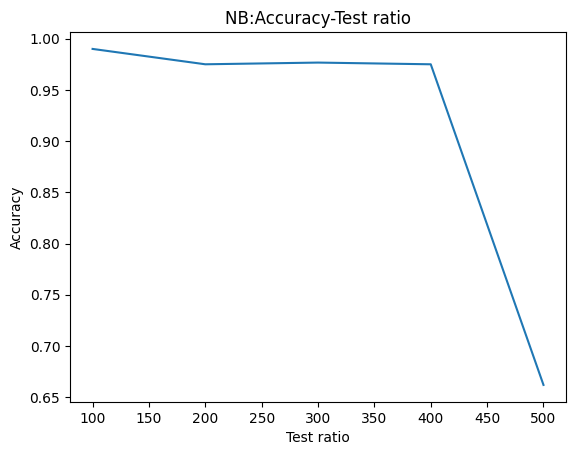

In [3]:
import NB_Comparison
import matplotlib.pyplot as plt

dataset = pd.read_csv('train_data.csv')
sample_number=len(dataset)
c = []
d = []
for r in range(100,sample_number,100):
  c.append(r)
  d.append(NB_Comparison.NB_comparison(sample_number,r))
plt.plot(c, d)
plt.xlabel("Test ratio")
plt.ylabel("Accuracy")
plt.title("NB:Accuracy-Test ratio")
plt.show()

Try your own data (Run the top cell first)

The number of students means how many valid rows of students' information in your excel file.

In [4]:
import digitalization
df = pd.read_excel("Input information.xlsx")
df1 = df.drop(['School_Information','ENGG2020'],axis=1)
pd.DataFrame(df1).to_csv('Personal_Information.csv',index=None)
dataset = pd.read_csv("Personal_Information.csv")
digitalization.predict(dataset)
student_number = int(input('Please input the number of students: ',))
X = dataset.iloc[:student_number,1:7].values
# print(X)

# Load the NB model
with open('NB.pickle', 'rb') as model_file:
    NB = pickle.load(model_file)

# Predicting the Test set results
y_pred = NB.predict(X)
print('Number of predictions: ', len(y_pred))
print('Predict Level: ', y_pred)
NB_df=pd.DataFrame(y_pred)
NB_df.columns = ['ENGG2020']
pd.DataFrame(NB_df).to_csv('NB_pred_level1.csv',index=None)
f1 = pd.read_csv('predict_data.csv')
f2 = pd.read_csv('NB_pred_level1.csv')
file = [f1,f2]
train = pd.concat(file,axis=1)
train.to_csv("Personal_NB_predict_complete" + ".csv", index=0, sep=',')

Please input the number of students: 2
Number of predictions:  2
Predict Level:  ['A' 'A']


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


If you want to add some extra columns of student features

In [5]:
import pickle
import pandas as pd
import NB
import digitalization_more

data = pd.read_csv("original_data_with_more_columns.csv")
digitalization_more.train(data)

NB.NB_model(factor_number=9, test_data_number=0.2)

df1 = pd.read_csv("data_to_predict_with_more_columns.csv")
dataset = df1.drop(['ENGG2020'],axis=1)
digitalization_more.predict(dataset)

X = dataset.iloc[:,1:9].values

# Load the NB model
with open('NB.pickle', 'rb') as model_file:
    NB = pickle.load(model_file)

# Predicting the Test set results
y_pred = NB.predict(X)
print('Number of predictions: ', len(y_pred))
NB_df=pd.DataFrame(y_pred)
NB_df.columns = ['ENGG2020']
pd.DataFrame(NB_df).to_csv('NB_pred_level2.csv',index=None)
f1 = pd.read_csv('predict_data.csv')
f2 = pd.read_csv('NB_pred_level2.csv')
file = [f1,f2]
train = pd.concat(file,axis=1)
train.to_csv("More_NB_predict_complete" + ".csv", index=0, sep=',')

Accuracy of the Naive Bayes Clasification is:  0.9908256880733946
Number of predictions:  545
